In [12]:
import pvlib
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
df_ground1 = pd.read_csv('Data/irradiation_measurements/ministry_energy_ug/cleaned/Soroti/Soroti_2020.csv')
df_ground2 = pd.read_csv('Data/irradiation_measurements/ministry_energy_ug/cleaned/Soroti/Soroti_2021.csv')

df_ground = pd.concat([df_ground1, df_ground2], ignore_index=True)
df_ground['Day'] = pd.to_datetime(df_ground['Day'])
df_ground.set_index('Day', inplace=True)
df_ground.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 700 entries, 2020-02-01 to 2021-12-31
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (C)         700 non-null    float64
 1   Temperature (SAT) (C)   700 non-null    float64
 2   Rain (mm)               700 non-null    float64
 3   GHI_1 (kWh/m2/day)      699 non-null    float64
 4   GHI_2 (kWh/m2/day)      699 non-null    float64
 5   GHI_SAT (kWh/m2/day)    699 non-null    float64
 6   GHI (1) vs (2) (%)      699 non-null    float64
 7   GHI (1) vs (SAT) (%)    699 non-null    float64
 8   DHI (1) (kWh/m2/day)    700 non-null    float64
 9   DHI (SAT) (kWh/m2/day)  700 non-null    float64
 10  DHI (1) vs (SAT) (%)    700 non-null    float64
dtypes: float64(11)
memory usage: 65.6 KB


In [ ]:
df_camsrad1 = pd.read_csv('Data/irradiation_estimates/ministry_energy_ug/Soroti/Soroti_CAMSRAD2020.csv')
df_camsrad2 = pd.read_csv('Data/irradiation_estimates/ministry_energy_ug/Soroti/Soroti_CAMSRAD2021.csv')


df_camsrad = pd.concat([df_camsrad1, df_camsrad2], ignore_index=True)
df_camsrad['Time'] = pd.to_datetime(df_camsrad['Time'])
df_camsrad.set_index('Time', inplace=True)
df_camsrad.sort_index(inplace=True)
df = df_camsrad.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2020-01-01 to 2021-12-31
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TAO (Wh/m2/day)            731 non-null    float64
 1   Clear sky GHI (Wh/m2/day)  731 non-null    float64
 2   Clear sky BHI (Wh/m2/day)  731 non-null    float64
 3   Clear sky DHI (Wh/m2/day)  731 non-null    float64
 4   Clear sky DNI (Wh/m2/day)  731 non-null    float64
 5   GHI (Wh/m2/day)            731 non-null    float64
 6   BHI (Wh/m2/day)            731 non-null    float64
 7   DHI (Wh/m2/day)            731 non-null    float64
 8   DNI (Wh/m2/day)            731 non-null    float64
 9   Reliability                731 non-null    float64
dtypes: float64(10)
memory usage: 62.8 KB


In [94]:
df['GHI_ground'] = df_ground['GHI_1 (kWh/m2/day)'] * 1000
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 699 entries, 2020-02-01 to 2021-12-31
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   TAO (Wh/m2/day)            699 non-null    float64
 1   Clear sky GHI (Wh/m2/day)  699 non-null    float64
 2   Clear sky BHI (Wh/m2/day)  699 non-null    float64
 3   Clear sky DHI (Wh/m2/day)  699 non-null    float64
 4   Clear sky DNI (Wh/m2/day)  699 non-null    float64
 5   GHI (Wh/m2/day)            699 non-null    float64
 6   BHI (Wh/m2/day)            699 non-null    float64
 7   DHI (Wh/m2/day)            699 non-null    float64
 8   DNI (Wh/m2/day)            699 non-null    float64
 9   Reliability                699 non-null    float64
 10  DayOfYear                  699 non-null    int32  
 11  Month                      699 non-null    int32  
 12  TAO_ClearSky_ratio         699 non-null    float64
 13  GHI_ground                 699 

In [93]:
# Coordinates for Soroti, Uganda
latitude = 1.7157
longitude = 33.6117

start_date = df_camsrad.index[0]
end_date = df_camsrad.index[-1]

days = pd.date_range(start=start_date, end=end_date, freq='h')[:-1]
days = days.tz_localize('Africa/Nairobi')


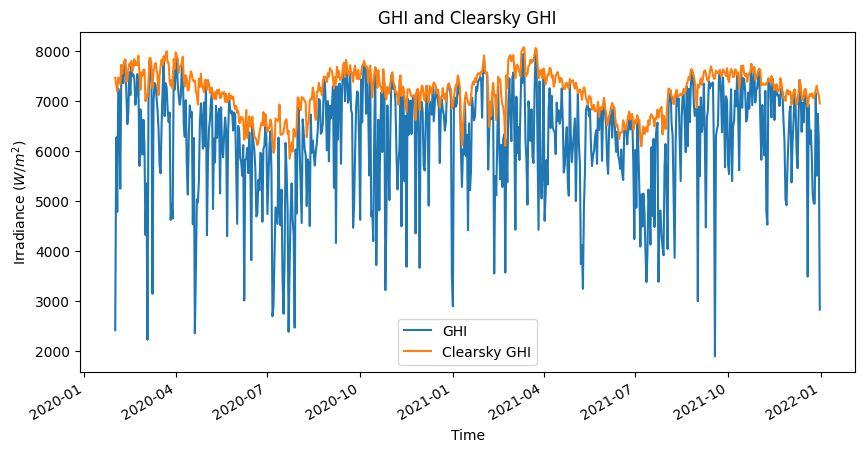

In [70]:
# plot clearsk GHI and GHI on the same axes
plt.figure(figsize=(10, 5))
df['GHI (Wh/m2/day)'].plot()
df['Clear sky GHI (Wh/m2/day)'].plot()
plt.ylabel('Irradiance ($W/m^2$)')
plt.title('GHI and Clearsky GHI')
plt.legend(['GHI', 'Clearsky GHI'])
plt.show()

In [71]:
df['DayOfYear'] = df.index.dayofyear
df['Month'] = df.index.month

In [72]:
df['TAO_ClearSky_ratio'] = df['Clear sky GHI (Wh/m2/day)'] / df['TAO (Wh/m2/day)']
df

,TAO (Wh/m2/day),Clear sky GHI (Wh/m2/day),Clear sky BHI (Wh/m2/day),Clear sky DHI (Wh/m2/day),Clear sky DNI (Wh/m2/day),GHI (Wh/m2/day),BHI (Wh/m2/day),DHI (Wh/m2/day),DNI (Wh/m2/day),Reliability,DayOfYear,Month,TAO_ClearSky_ratio,GHI_ground
Time,,,,,,,,,,,,,,
2020-02-01,10083.9512,7464.2241,6379.7529,1084.4712,9317.4248,2421.3127,309.8050,2111.5078,598.7863,0.9861,32,2,0.740208,2.55
2020-02-02,10099.2256,7318.9775,5752.5747,1566.4027,8144.4272,6273.2861,3615.2991,2657.9871,4698.7358,0.9858,33,2,0.724707,6.10
2020-02-03,10114.4111,7189.5391,5358.0029,1831.5360,7450.6343,4786.0259,2882.8804,1903.1456,3573.7090,0.9858,34,2,0.710821,4.69
2020-02-04,10129.5293,7467.6865,6133.9561,1333.7300,8806.7646,7247.5830,5693.9521,1553.6307,7733.1172,0.9806,35,2,0.737219,6.69
2020-02-05,10144.5615,7432.5483,5925.8823,1506.6659,8401.2637,7097.7856,5193.4819,1904.3037,7177.3477,0.9858,36,2,0.732663,6.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,9672.8975,7219.7251,6119.3618,1100.3635,9281.3604,7154.5005,6002.3853,1152.1151,8865.5938,0.9865,361,12,0.746387,6.24
2021-12-28,9677.6084,7306.5361,6230.4907,1076.0455,9509.7920,5508.3677,1715.1237,3793.2444,2844.5793,0.9861,362,12,0.754994,5.21
2021-12-29,9682.7803,7183.1548,5957.1460,1226.0087,9145.4268,6745.3301,5049.2422,1696.0880,7862.9927,0.9865,363,12,0.741848,6.83


In [127]:
# Define the features to be used for training
features = ['DayOfYear', 'TAO_ClearSky_ratio']

In [128]:
train = df.loc['2020']
test = df.loc['2021']

In [129]:
from sklearn.metrics import mean_absolute_error, r2_score

camsrad_mae = mean_absolute_error(test['GHI (Wh/m2/day)'], test['GHI_ground'])
camsrad_r2 = r2_score(test['GHI (Wh/m2/day)'], test['GHI_ground'])

print(f'CAMSRAD MAE: {camsrad_mae}')
print(f'CAMSRAD R2: {camsrad_r2}')


CAMSRAD MAE: 331.94885232876715
CAMSRAD R2: 0.8267770356301333


In [130]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(train[features], train['GHI_ground'])

LinearRegression()

In [145]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3)
model_gb.fit(train[features], train['GHI_ground'])

GradientBoostingRegressor(n_estimators=200)

<Axes: >

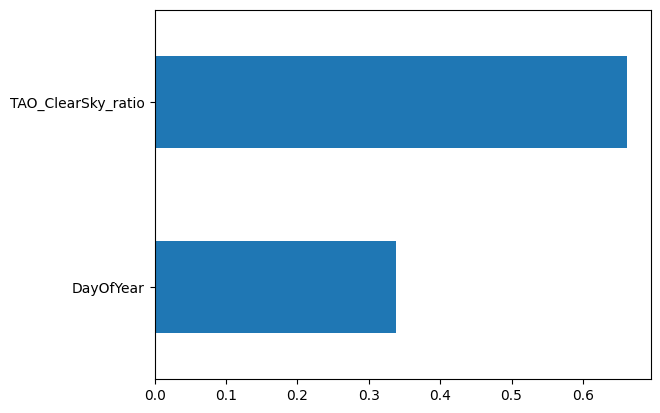

In [132]:
pd.Series(model_gb.feature_importances_, index=features).sort_values().plot(kind='barh')

In [146]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return mae, r2

# Test GB model
gb_mae, gb_r2 = evaluate(model_gb, test[features], test['GHI_ground'])

print(f"CAMSRAD MAE: {camsrad_mae:.2f}, GB MAE: {gb_mae:.2f}")
print(f"CAMSRAD R²: {camsrad_r2:.2f}, GB R²: {gb_r2:.2f}")

CAMSRAD MAE: 331.95, GB MAE: 834.41
CAMSRAD R²: 0.83, GB R²: -0.20


In [138]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return mae, r2

# Test GB model
gb_mae, gb_r2 = evaluate(model_lr, test[features], test['GHI_ground'])

print(f"CAMSRAD MAE: {camsrad_mae:.2f}, GB MAE: {gb_mae:.2f}")
print(f"CAMSRAD R²: {camsrad_r2:.2f}, GB R²: {gb_r2:.2f}")

CAMSRAD MAE: 331.95, GB MAE: 685.01
CAMSRAD R²: 0.83, GB R²: 0.20


In [148]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=3)
)
grid_search.fit(train[features], train['GHI (Wh/m2/day)'])
best_model = grid_search.best_estimator_
# print all parameters of the best model
print(best_model.get_params())

{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.05, 'loss': 'squared_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': None, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


In [149]:
best_model_mae, best_model_r2 = evaluate(best_model, test[features], test['GHI (Wh/m2/day)'])
print(f"Best model MAE: {best_model_mae:.2f}, R²: {best_model_r2:.2f}")

Best model MAE: 800.91, R²: -0.18


In [150]:
ghi_pred = best_model.predict(df[features])
ghi_pred = pd.Series(ghi_pred, index=df.index)

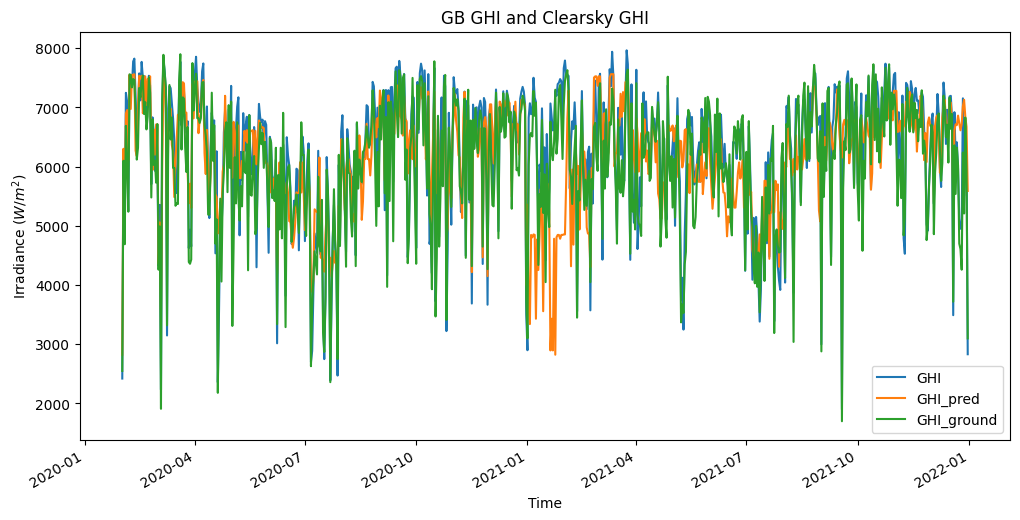

In [152]:
# plot clearsk GHI, ghi pred and GHI ground on the same axes
plt.figure(figsize=(12, 6))
df['GHI (Wh/m2/day)'].plot()
ghi_pred.plot()
df['GHI_ground'].plot()
plt.ylabel('Irradiance ($W/m^2$)')
plt.title('GB GHI and Clearsky GHI')
plt.legend(['GHI', 'GHI_pred', 'GHI_ground'])
plt.show()

In [153]:
ghi_pred = model_lr.predict(df[features])
ghi_pred = pd.Series(ghi_pred, index=df.index)

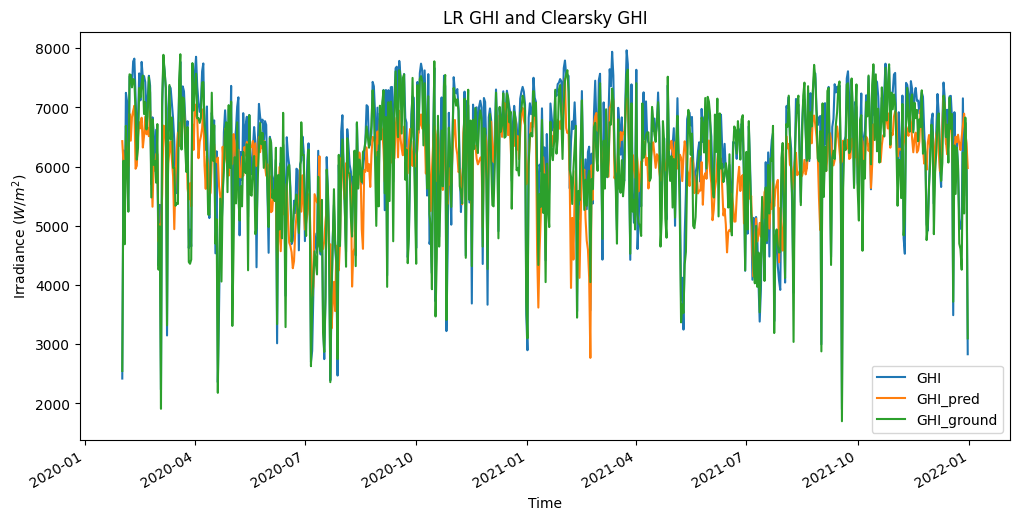

In [156]:
# plot clearsk GHI, ghi pred and GHI ground on the same axes
plt.figure(figsize=(12, 6))
df['GHI (Wh/m2/day)'].plot()
ghi_pred.plot()
df['GHI_ground'].plot()
plt.ylabel('Irradiance ($W/m^2$)')
plt.title('LR GHI and Clearsky GHI')
plt.legend(['GHI', 'GHI_pred', 'GHI_ground'])
plt.show()